### **Content**
- Resampling
- Performance metrics for time series

In [1]:
# Standard library imports
import warnings
from pathlib import Path

# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    mean_absolute_error, 
    mean_squared_error, 
    mean_absolute_percentage_error
)

# Configure plotting
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (20, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)


ModuleNotFoundError: No module named 'matplotlib'

Let's use the same dataset as the one in lecture: **Mobilplus sales forecasting usecase**

We will look into this time series data in depth during the lecture. For now, we're just using this

In [ ]:
data_path = Path('data/mobilesales.xlsx')

try:
    mobile_sales = pd.read_excel(data_path)
    print(f"Dataset shape: {mobile_sales.shape}")
    print(f"Date range: {mobile_sales['DATE'].min()} to {mobile_sales['DATE'].max()}")
    display(mobile_sales.head())
    
except FileNotFoundError:
    print(f"Error: File not found at {data_path}")

except Exception as e:
    print(f"Error loading dataset: {e}")

Dataset shape: (217, 2)
Date range: 2001-01-01 00:00:00 to 2019-01-01 00:00:00


,DATE,Sales
0,2001-01-01,6519.0
1,2001-02-01,6654.0
2,2001-03-01,7332.0
3,2001-04-01,7332.0
4,2001-05-01,8240.0


In [ ]:
# Set DATE column as index for time series analysis
mobile_sales = mobile_sales.set_index('DATE')

# Ensure the index is datetime type
mobile_sales.index = pd.to_datetime(mobile_sales.index)

# Check for missing values
print(f"\nMissing values: {mobile_sales.isnull().sum().sum()}")

if mobile_sales.isnull().sum().sum() > 0:
    print("Missing values detected:")
    print(mobile_sales.isnull().sum())


Missing values: 19
Missing values detected:
Sales    19
dtype: int64


In [ ]:
print("\nDataset info:")
print(mobile_sales.info())


Dataset info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 217 entries, 2001-01-01 to 2019-01-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Sales   198 non-null    float64
dtypes: float64(1)
memory usage: 3.4 KB
None




### **Resampling**

#### **Resampling in Time Series**

Looking at the datetime column, pandas can figure out that our data is indexed monthly.

If instead of forecasting for a couple of months, the client wants us to forecast the data for the next 3 years, we use **resampling**.

**Resampling** means changing the frequency of the time series data (e.g., monthly → yearly or monthly → daily).


#### **Downsampling (Monthly → Yearly)**

- **Process**: Convert higher frequency (**monthly**) data into lower frequency (**yearly**).
- **Method**: Use `groupby` or `resample`.
- **Example**:
    - Monthly Qty (2008-01, 2008-02, …, 2008-12) → aggregated into Yearly Qty (2008).
    - Formula: `Qty(year) = Sum of Qty for all months in that year`.
- **Effect**: Data shrinks (**fewer rows, summarized view**).


#### **Upsampling (Monthly → Daily)**


- **Process**: Convert lower frequency (**monthly**) data into higher frequency (**daily**).
- **Method**: Distribute monthly value across days (often using average).
- **Example**:
    - If monthly Qty = X (in February with 28 days):
        - Each day gets `X / 28`.
        - Repeats for all days in the month.
- **Effect**: Data expands (**more rows, but values are spread out**).

- **Downsampling** = **Aggregate** → fewer data points (monthly → yearly).
- **Upsampling** = **Spread out** → more data points (monthly → daily).

- Monthly → Yearly is called **downsampling**.
- It is simple, as we can just take the **sum of all data points** in a bucket to obtain the downsampled value.


In [ ]:
# Upsample monthly data to yearly data using sum aggregation
yearly_sales = mobile_sales.resample('Y').sum()

print(f"Original data points: {len(mobile_sales)}")
print(f"Yearly data points: {len(yearly_sales)}")

print("\nYearly sales data:")
display(yearly_sales.head())

Original data points: 217
Yearly data points: 19

Yearly sales data:


,Sales
DATE,
2001-12-31,92119.0
2002-12-31,72070.0
2003-12-31,91843.0
2004-12-31,104200.0
2005-12-31,100343.0


In [ ]:
# Display summary statistics
print(yearly_sales.describe())

               Sales
count      19.000000
mean   112992.947368
std     33502.869147
min     12160.000000
25%    102271.500000
50%    114332.000000
75%    132059.000000
max    173459.000000


Notice that here, instead of monthly data, we get one data point for each year, with the date set as 31st December for each year.


Lets plot this yearly data, to see how it looks.

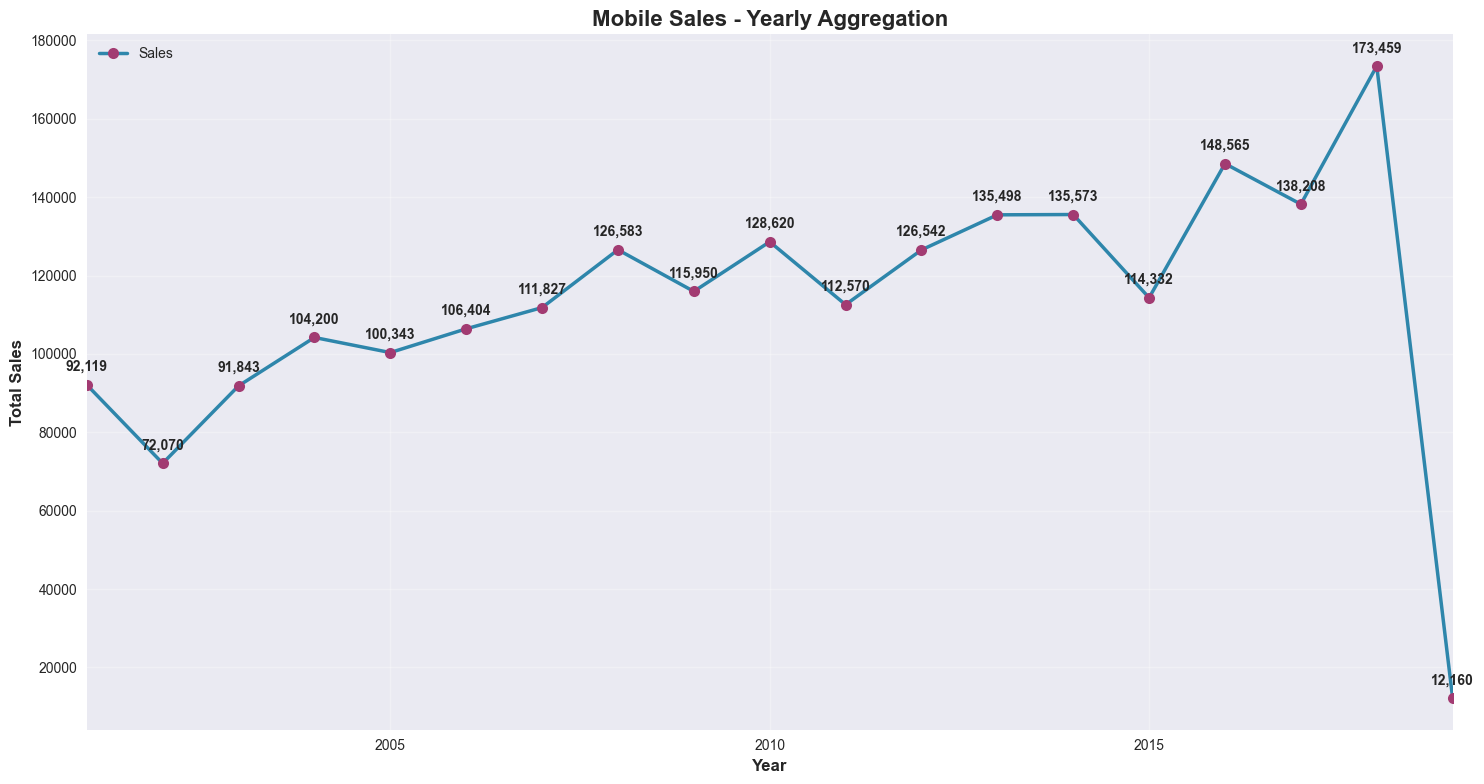

In [ ]:
fig, ax = plt.subplots(figsize=(15, 8))

yearly_sales.plot(ax=ax, style='-o', 
                  linewidth=2.5, 
                  markersize=8, 
                  color='#2E86AB', 
                  markerfacecolor='#A23B72')

# Customize the plot
ax.set_title('Mobile Sales - Yearly Aggregation', fontsize=16, fontweight='bold')
ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Sales', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)


# Add value annotations on data points
for i, (idx, row) in enumerate(yearly_sales.iterrows()):
    ax.annotate(f'{row["Sales"]:,.0f}', 
                (idx, row['Sales']), 
                textcoords="offset points", 
                xytext=(0,10), 
                ha='center',
                fontsize=10,
                fontweight='bold')

plt.tight_layout()
plt.show()


In [ ]:

print("Yearly Sales Insights:")
highest_year = yearly_sales['Sales'].idxmax()
lowest_year = yearly_sales['Sales'].idxmin()

# Ensure highest_year and lowest_year are Timestamps
highest_year = pd.to_datetime(highest_year)
lowest_year = pd.to_datetime(lowest_year)

print(f"• Highest sales year: {highest_year.year} ({yearly_sales['Sales'].max()})")
print(f"• Lowest sales year: {lowest_year.year} ({yearly_sales['Sales'].min()})")
print(f"• Average yearly sales: {yearly_sales['Sales'].mean()}")
print(f"• Sales growth rate: {((yearly_sales['Sales'].iloc[-1] / yearly_sales['Sales'].iloc[0]) - 1) * 100:.1f}%")

Yearly Sales Insights:
• Highest sales year: 2018 (173459.0)
• Lowest sales year: 2019 (12160.0)
• Average yearly sales: 112992.94736842105
• Sales growth rate: -86.8%


* **Sales growth rate** → Compares the **first year’s sales vs the last year’s sales** to show overall % growth (or decline).

“This gives a clear picture of which year performed best and worst, what a normal year looks like on average, and how much overall sales have grown (or dropped) from start to end.”



> **Q. So What exactly is resampling?**

Since we are looking at time series data, there may arise situations where we wish to manipulate the time frame of our data (seconds, days, months, years).

Resampling means sampling the existing data according to our requirement, by either upsampling or downsampling.

<br>

> **Q. Why do we need to perform resampling?**

In practice, there are 2 main reasons why using resample.
1. To inspect how data behaves differently under different resolutions or frequency.
2. To join datasets/tables with different resolutions.


<br>

> **Q. Are there any pre requisites to resampling?**

There are 2 prerequisites to carry out resampling:

1. The Datetime column must be in “datetime” or “timestamp” data type.
2. The Datetime column must be the index. 
 - Alternatively, you can use the ‘on’ parameter to define the column to carry out resampling (not supported in upsampling).

As you can see, both these conditions are already met in our dataset.

 <br>

> **Q. Why did we use `sum()`, is there any other way of doing resampling?**

During resampling, we used the `sum()` method, because it makes logical sense to add up the monthly sales in order to obtain the yearly sale values.

Yes, there are other ways of resampling.

Instead of `sum()`, we could've theoretically used other methods such as `max(), min(), or mean()`. 

But in the context of upsampling in time series, that does not make sense.

We saw how we can upsample our data, by taking sum. 

> **Q. Can we downsample data as well?**

Yes.

Let's try downsampling by finding data indexed by **day**.

For doing so, we will use `'D'` inside the `resample()` method.

In [ ]:
# Attempt downsampling from monthly to daily data
# This will create many NaN values as we don't have daily data points.

daily_sales = mobile_sales.resample('D').sum()

print(f"Original monthly data points: {len(mobile_sales)}")
print(f"Daily data points: {len(daily_sales)}")
print(f"Non-null daily data points: {daily_sales['Sales'].notna().sum()}")

print("\nFirst 10 rows of daily data:")
display(daily_sales.head(10))

Original monthly data points: 217
Daily data points: 6575
Non-null daily data points: 6575

First 10 rows of daily data:


,Sales
DATE,
2001-01-01,6519.0
2001-01-02,0.0
2001-01-03,0.0
2001-01-04,0.0
2001-01-05,0.0
2001-01-06,0.0
2001-01-07,0.0
2001-01-08,0.0
2001-01-09,0.0


In [ ]:
# Show the problem - most values are NaN
print(f"\nProblem: {daily_sales['Sales'].isna().sum()} out of {len(daily_sales)} days have NaN values")
print("This happens because we're trying to create daily data from monthly data.")


Problem: 0 out of 6575 days have NaN values
This happens because we're trying to create daily data from monthly data.


Uh-oh, there seems to be a problem!

<br>

> **Q. What went wrong in downsampling?**

We are trying to find out daily sales data from the given monthly sales data.

And we used `sum()` method as the aggregate function for resampling.

So, technically, nothing went wrong 
- We were able to successfully obtain daily sales data such that 
- the sum of daily mobile sales in a month is in fact equal to the monthly sale values.

We are essentially trying to fill in the values that we don't have.

<br>

> **Q. How do we go about solving this problem?**

Intuitively, we can think that if the number of mobiles sold in a month, say January is X, then the number of mobiles sold each day is $\frac{X}{31}$, where 31 is the number of days in the month of January.

$$\frac{X}{31} + \frac{X}{31} + ... + \frac{X}{31} \text{ (31 times)} = X$$

This will give us the best estimate for daily data

<br>

So we use **forward fill** here, which replaces all values of days in January with the monthly value of January, and then we can simply divide this with the number of months in January i.e. 31

<br>

> **Q. So essentially we're taking the average of values, why not just change the aggregate function to `mean()`?**

This makes logical sense, Let's try doing this.

In [ ]:
# Try using mean() instead of sum() for downsampling

daily_sales_mean = mobile_sales.resample('D').mean()

print(f"Daily data points: {len(daily_sales_mean)}")
print(f"Non-null daily data points: {daily_sales_mean['Sales'].notna().sum()}")

display(daily_sales_mean.head(10))

Daily data points: 6575
Non-null daily data points: 198


,Sales
DATE,
2001-01-01,6519.0
2001-01-02,NaN
2001-01-03,NaN
2001-01-04,NaN
2001-01-05,NaN
2001-01-06,NaN
2001-01-07,NaN
2001-01-08,NaN
2001-01-09,NaN


In [ ]:

print(f"\nProblem: {daily_sales_mean['Sales'].isna().sum()} out of {len(daily_sales_mean)} days still have NaN values")
print("The mean() method only assigns values to the first day of each month, leaving other days as NaN.")


Problem: 6377 out of 6575 days still have NaN values
The mean() method only assigns values to the first day of each month, leaving other days as NaN.


As you can see, using `mean()` as the aggregate function just ends up assigning the monthly value to the 1st of each month, and assigns all other days' sales value as **NaN**.

In [ ]:
# Create a proper downsampling solution using forward fill and division

# Step 1: Resample to daily and forward fill
temp = mobile_sales.resample('D').mean().ffill()  

# Step 2: Ensure index is DatetimeIndex and create year-month identifier
temp.index = pd.DatetimeIndex(temp.index)
temp['year_month'] = temp.index.to_series().dt.year * 100 + temp.index.to_series().dt.month

# Step 3: Count days in each month
temp['days_in_month'] = temp.groupby('year_month')['Sales'].transform('count')

# Step 4: Divide monthly sales by days in month to get daily average
temp['Sales'] = temp['Sales'] / temp['days_in_month']

# Clean up temporary columns
daily_sales_proper = temp[['Sales']].copy()

print(f"Daily data points: {len(daily_sales_proper)}")
print(f"Non-null daily data points: {daily_sales_proper['Sales'].notna().sum()}")

display(daily_sales_proper.head(10))


Daily data points: 6575
Non-null daily data points: 6575


,Sales
DATE,
2001-01-01,210.290323
2001-01-02,210.290323
2001-01-03,210.290323
2001-01-04,210.290323
2001-01-05,210.290323
2001-01-06,210.290323
2001-01-07,210.290323
2001-01-08,210.290323
2001-01-09,210.290323


> **Q. Why bother performing downsampling?**

Though, this is not adding any more information, there may arise a situation where we need to resample just because we need to **mix up** another signal which is in daily level.

So, in order to mix the two signals, we need to first downsample our given data, which is in monthly level.

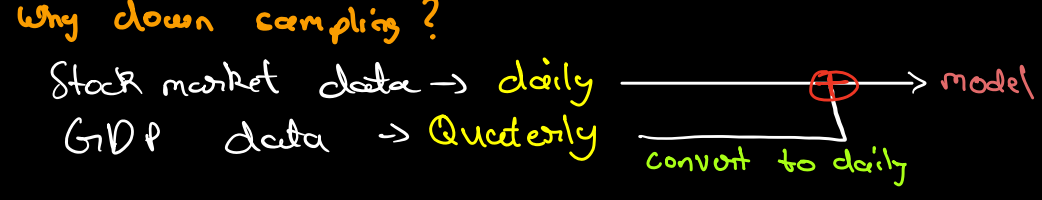

<br>



### **Performance Metrics in a time series**

Before getting into performance metrics, Let's do all the data processing we learnt about in the lecture
- Setting index as date
- Perform linear interpolation
- Taking care of anomalies by clipping values using quantiles
- Plotting the resultant time series

In [ ]:
# Data preprocessing for time series analysis

processed_sales = mobile_sales.copy()

# Step 1: Linear interpolation for missing values
missing_before = processed_sales['Sales'].isnull().sum()
processed_sales['Sales'] = processed_sales['Sales'].interpolate(method='linear')
missing_after = processed_sales['Sales'].isnull().sum()

print(f"   • Missing values before: {missing_before}")
print(f"   • Missing values after: {missing_after}")


   • Missing values before: 19
   • Missing values after: 0


In [ ]:
# Step 2: Handle anomalies using quantile clipping
print("Step 2: Anomaly detection and clipping")

lower_bound = processed_sales['Sales'].quantile(0.02)
upper_bound = processed_sales['Sales'].quantile(0.98)

print(f"   • Lower bound (2nd percentile): {lower_bound:.2f}")
print(f"   • Upper bound (98th percentile): {upper_bound:.2f}")


Step 2: Anomaly detection and clipping
   • Lower bound (2nd percentile): 6802.44
   • Upper bound (98th percentile): 15809.40


In [ ]:
# Count outliers before clipping
outliers_before = ((processed_sales['Sales'] < lower_bound) | 
                   (processed_sales['Sales'] > upper_bound)).sum()

processed_sales['Sales'] = processed_sales['Sales'].clip(
    lower=lower_bound, 
    upper=upper_bound
)

outliers_after = ((processed_sales['Sales'] < lower_bound) | 
                  (processed_sales['Sales'] > upper_bound)).sum()

print(f"   • Outliers before clipping: {outliers_before}")
print(f"   • Outliers after clipping: {outliers_after}")


   • Outliers before clipping: 0
   • Outliers after clipping: 0


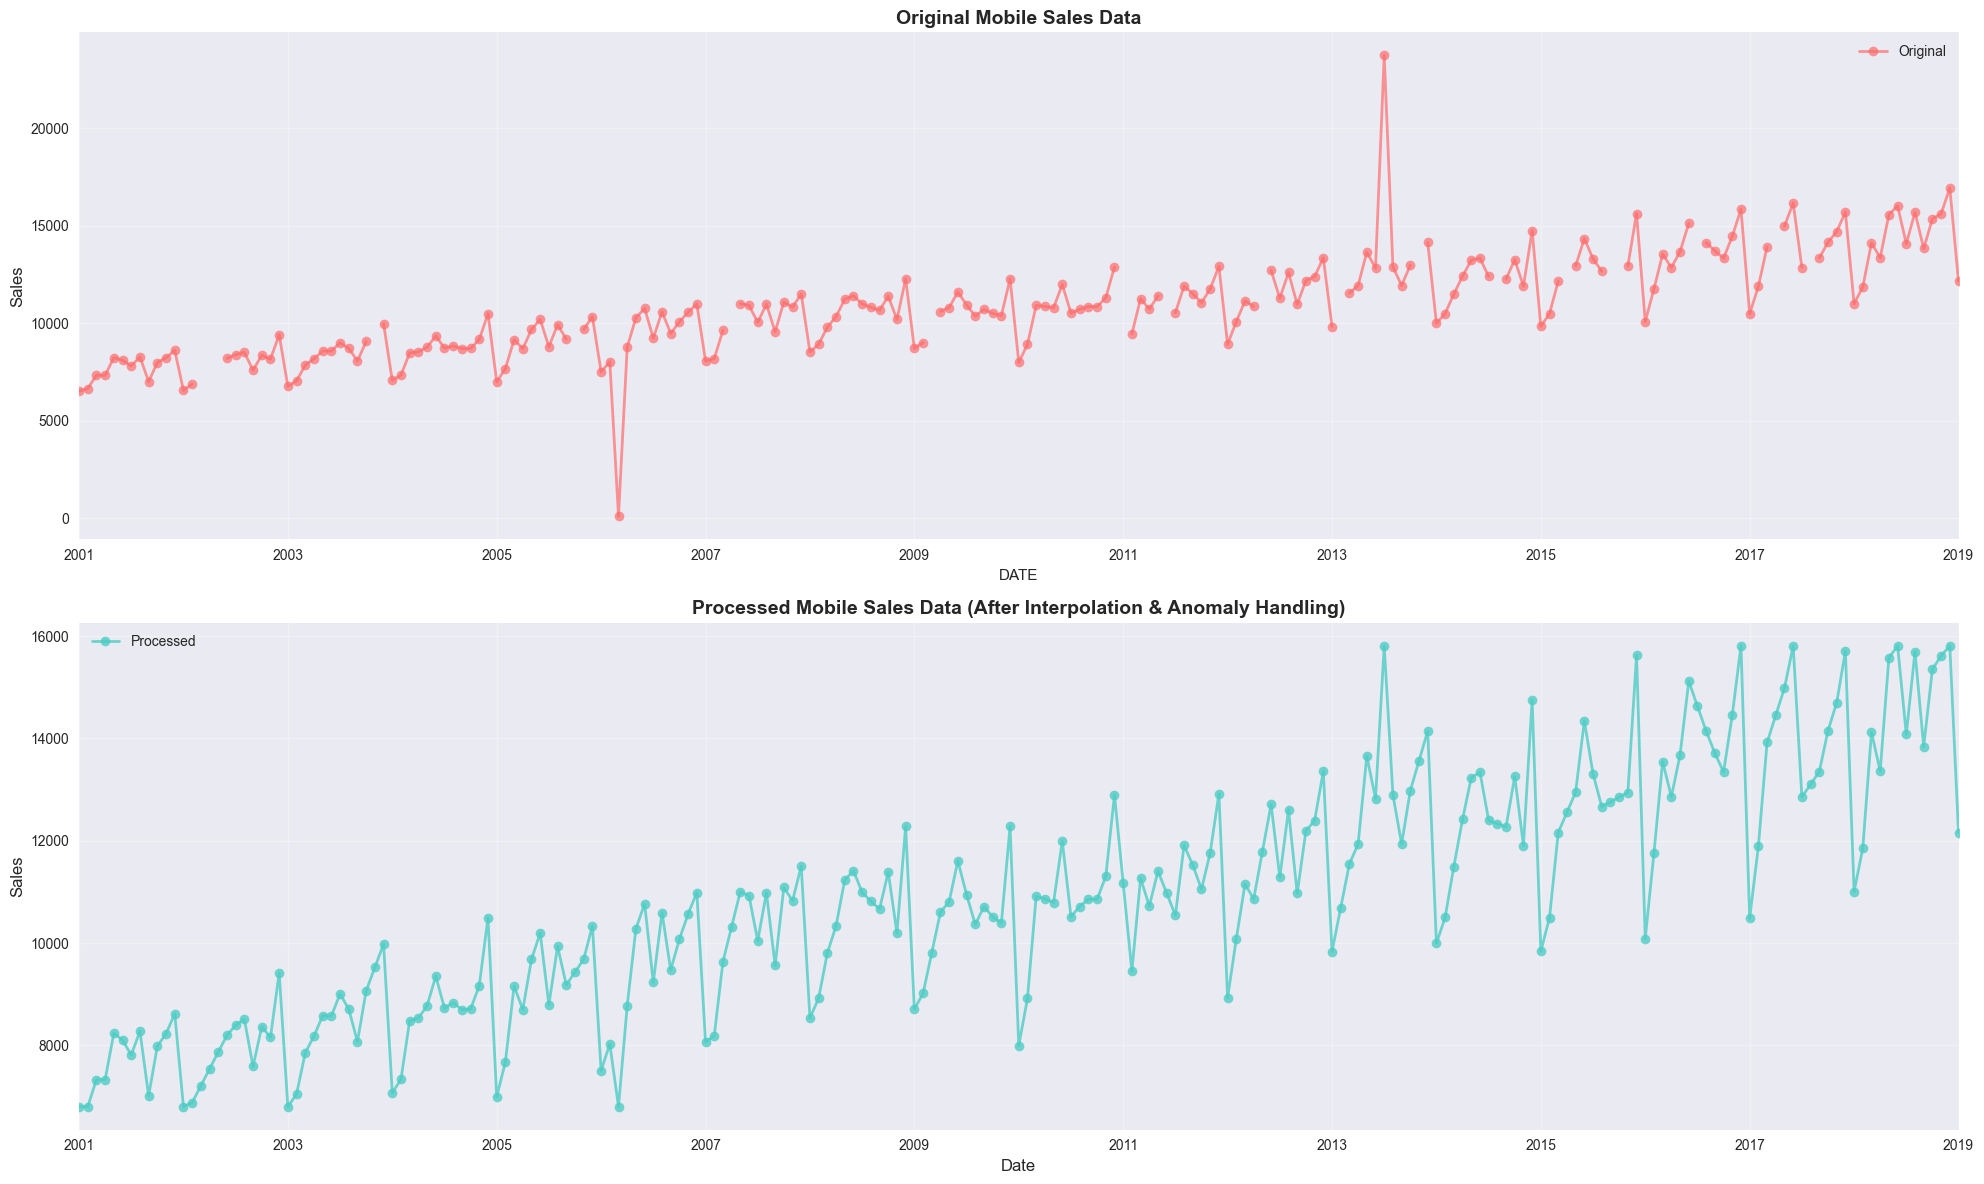

In [ ]:
# Step 3: Create enhanced visualization

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 12))

# Original data
mobile_sales['Sales'].plot(ax=ax1, style='-o', linewidth=2, 
                          color='#FF6B6B', alpha=0.7, label='Original')
ax1.set_title('Original Mobile Sales Data', fontsize=14, fontweight='bold')
ax1.set_ylabel('Sales', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Processed data
processed_sales['Sales'].plot(ax=ax2, style='-o', linewidth=2, 
                             color='#4ECDC4', alpha=0.8, label='Processed')
ax2.set_title('Processed Mobile Sales Data (After Interpolation & Anomaly Handling)', 
              fontsize=14, fontweight='bold')
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Sales', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()


In [ ]:

print(f"Final dataset shape: {processed_sales.shape}")
print(f"Sales range: {processed_sales['Sales'].min():.2f} to {processed_sales['Sales'].max():.2f}")

Final dataset shape: (217, 1)
Sales range: 6802.44 to 15809.40


In [ ]:
# Split data into training and testing sets for time series forecasting

# Use the last 12 months for testing (typical for monthly data)
test_size = 12
split_date = processed_sales.index[-test_size]

# Create train and test sets
train_data = processed_sales.loc[processed_sales.index < split_date].copy()
test_data = processed_sales.loc[processed_sales.index >= split_date].copy()

print(f"Training data: {len(train_data)} months ({train_data.index.min().strftime('%Y-%m')} to {train_data.index.max().strftime('%Y-%m')})")
print(f"Testing data: {len(test_data)} months ({test_data.index.min().strftime('%Y-%m')} to {test_data.index.max().strftime('%Y-%m')})")

print(f"Training data percentage: {len(train_data) / len(processed_sales) * 100:.1f}%")
print(f"Testing data percentage: {len(test_data) / len(processed_sales) * 100:.1f}%")


Training data: 205 months (2001-01 to 2018-01)
Testing data: 12 months (2018-02 to 2019-01)
Training data percentage: 94.5%
Testing data percentage: 5.5%


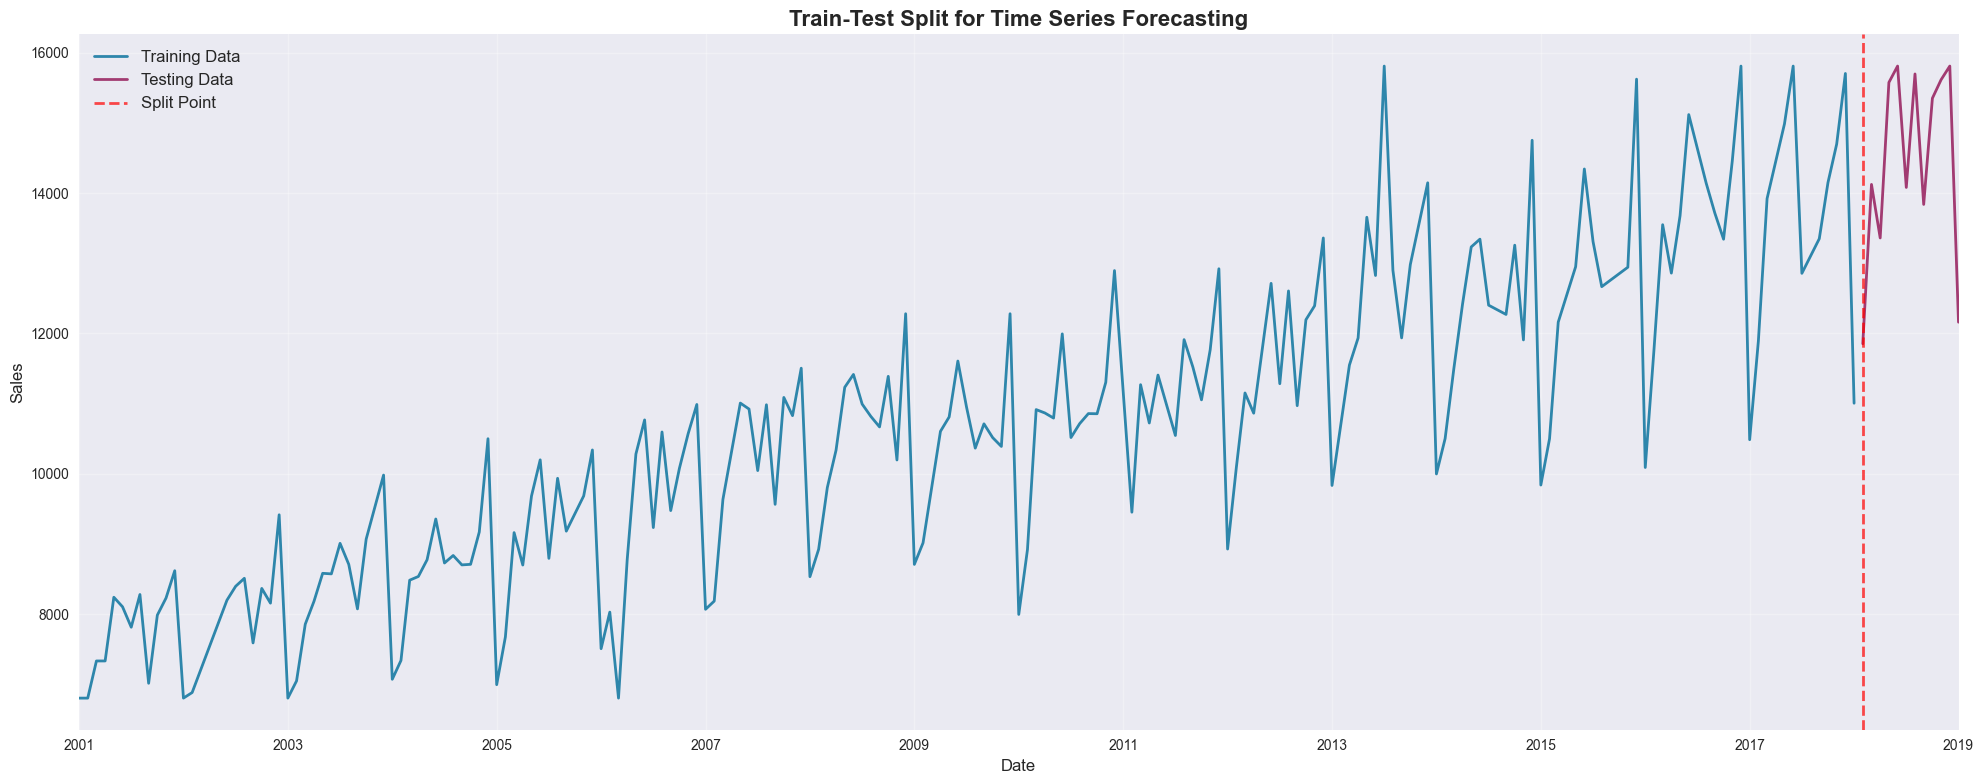

In [ ]:

# Visualize the split
fig, ax = plt.subplots(figsize=(20, 8))

train_data['Sales'].plot(ax=ax, label='Training Data', color='#2E86AB', linewidth=2)
test_data['Sales'].plot(ax=ax, label='Testing Data', color='#A23B72', linewidth=2)

ax.axvline(x=split_date, color='red', linestyle='--', alpha=0.7, linewidth=2, label='Split Point')
ax.set_title('Train-Test Split for Time Series Forecasting', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Sales', fontsize=12)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Let's take a look at a few performance metrics that help us evaluate how good or bad our forecasts are in a time series, by implementing them over a simple **Naive Model** of forecasting.

You have already learnt all of these metrics.

Let's see them getting used in context of time series.

In [ ]:
# Implement Naive Forecasting Model

# Create predictions using naive method (last value)
last_value = train_data['Sales'].iloc[-1]
test_data['naive_prediction'] = last_value

print(f"Last training value: {last_value:.2f}")
print(f"This value will be used as prediction for all {len(test_data)} test periods")


Last training value: 11005.00
This value will be used as prediction for all 12 test periods


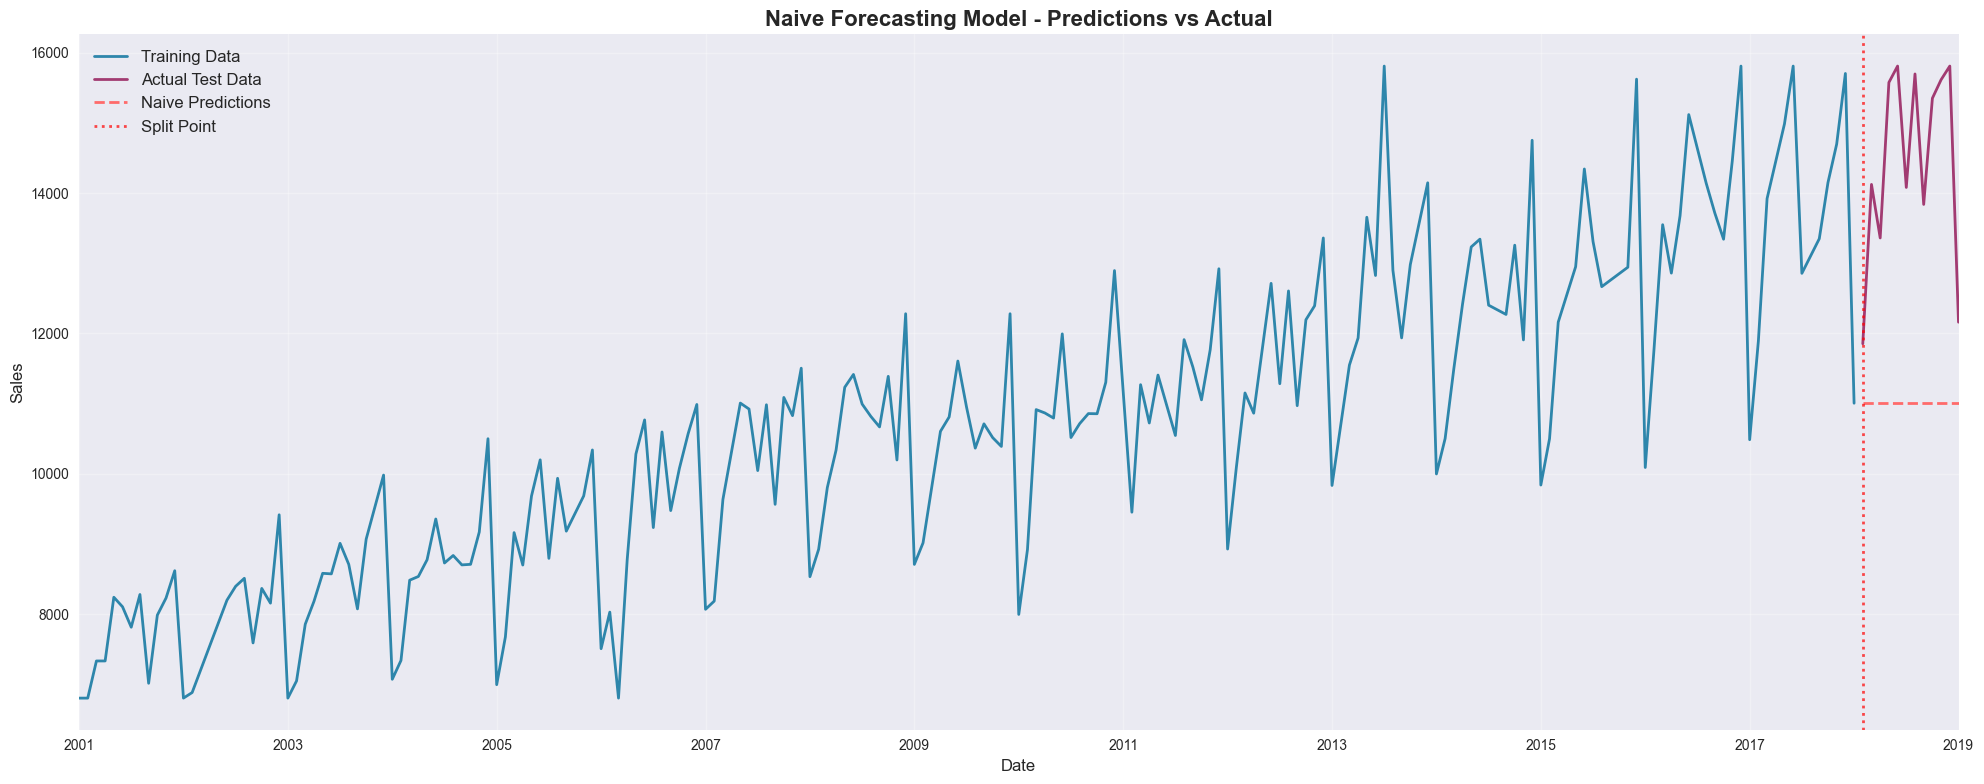

,Actual,Naive_Prediction,Error
DATE,,,
2018-02-01,11852.0,11005.0,847.0
2018-03-01,14123.0,11005.0,3118.0
2018-04-01,13360.0,11005.0,2355.0
2018-05-01,15576.0,11005.0,4571.0
2018-06-01,15809.4,11005.0,4804.4
2018-07-01,14080.0,11005.0,3075.0
2018-08-01,15697.0,11005.0,4692.0
2018-09-01,13838.0,11005.0,2833.0
2018-10-01,15351.0,11005.0,4346.0


In [ ]:

# Create visualization of naive predictions
fig, ax = plt.subplots(figsize=(20, 8))

# Plot training data
train_data['Sales'].plot(ax=ax, label='Training Data', color='#2E86AB', linewidth=2)

# Plot actual test data
test_data['Sales'].plot(ax=ax, label='Actual Test Data', color='#A23B72', linewidth=2)

# Plot naive predictions
test_data['naive_prediction'].plot(ax=ax, label='Naive Predictions', 
                                   color='#FF6B6B', linestyle='--', linewidth=2)

ax.axvline(x=split_date, color='red', linestyle=':', alpha=0.7, linewidth=2, label='Split Point')
ax.set_title('Naive Forecasting Model - Predictions vs Actual', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Sales', fontsize=12)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

comparison_df = pd.DataFrame({
    'Actual': test_data['Sales'],
    'Naive_Prediction': test_data['naive_prediction'],
    'Error': test_data['Sales'] - test_data['naive_prediction']
})
display(comparison_df.head(10))

#### **1. Mean Error**

ME is a measure of the average of the difference between each Actual and predicted value.

The formula for Mean Absolute Error is as follows:


$$ME = \frac{1}{N} \sum_{i=1}^{N} (y_{i} - \hat{y}_{i})$$

In the above equation, 

- $\hat{y}$ → predicted value
- $y$ → actual value  
- $N$ → total no. of observations

**AIM:** to get a ME value near 0

In [ ]:
# Calculate Mean Error (ME)

actual_values = test_data['Sales']
predicted_values = test_data['naive_prediction']

# Calculate Mean Error
mean_error = np.mean(actual_values - predicted_values)

print(f"Mean Error (ME): {mean_error:.4f}")
print(f"Interpretation: {'Positive' if mean_error > 0 else 'Negative'} bias of {abs(mean_error):.2f} units")

# Additional insights
print(f"   • Total positive errors: {(actual_values - predicted_values > 0).sum()}")
print(f"   • Total negative errors: {(actual_values - predicted_values < 0).sum()}")

Mean Error (ME): 3434.2333
Interpretation: Positive bias of 3434.23 units
   • Total positive errors: 12
   • Total negative errors: 0



**Note:** This is the same as **residual** we looked in the lecture.

<br>

#### **Q. What do we want our residual to look like?**
- Ideally we would like a value near 0, this way we know that even though sometimes we overpredict or underpredict, on an average, we're getting negligible error.
- Expected to be **normal** distribution.
- Have lower standard deviation.

<br>

#### **Q. What is the problem with ME?**
The problem is that, positive and negative errors cancel each other's effect. 

So we can get a very good ME score, but the model would actually be performing very bad.

#### **2. Mean Absolute Error (MAE)**

So to overcome this cancellation of negative and positive errors we use **Mean Absolute error** which takes the **absolute error of the terms** 

Mean Absolute Error is a measure of the average of the absolute difference between each Actual and predicted value.  

The formula for Mean Absolute Error is as follows:


$$MAE = \frac{1}{N} \sum_{i=1}^{N}\left | y_{i}-\hat{y}_{i} \right |$$

In [ ]:
# Calculate Mean Absolute Error (MAE)
# Using sklearn's implementation
mae_sklearn = mean_absolute_error(actual_values, predicted_values)

# Manual calculation for understanding
mae_manual = np.mean(np.abs(actual_values - predicted_values))

print(f"MAE (sklearn): {mae_sklearn:.4f}")
print(f"MAE (manual): {mae_manual:.4f}")
print(f"Interpretation: Average absolute deviation of {mae_sklearn:.2f} units from actual values")

# Additional insights
print(f"\n📈 MAE Analysis:")
print(f"   • Maximum absolute error: {np.max(np.abs(actual_values - predicted_values)):.2f}")
print(f"   • Minimum absolute error: {np.min(np.abs(actual_values - predicted_values)):.2f}")
print(f"   • Standard deviation of absolute errors: {np.std(np.abs(actual_values - predicted_values)):.2f}")

MAE (sklearn): 3434.2333
MAE (manual): 3434.2333
Interpretation: Average absolute deviation of 3434.23 units from actual values

📈 MAE Analysis:
   • Maximum absolute error: 4804.40
   • Minimum absolute error: 847.00
   • Standard deviation of absolute errors: 1368.90



**AIM:** to get a minimum MAE value

This will always be a positive value.

#### **3. Mean Square Error (MSE)**
- Takes the average of the square of the difference between the original values and the predicted values.
- As we take square of the error, the effect of **larger errors** (sometimes outliers) become **more pronounced** then smaller error as a result of which model will be **penalized more for bad predictions**.
- Before applying MSE, we must **eliminate all nulls/infinites** from the input.
- **Not robust** to outliers
- **Range (0, + infinity]**

Formula to calculate MSE is as follows:

$$MSE = \frac{1}{N}\sum_{i=1}^{N} (y_{i} - \hat{y}_{i})^2$$

**AIM:** To get minimum MSE value

In [ ]:

mse_sklearn = mean_squared_error(actual_values, predicted_values)
mse_manual = np.mean((actual_values - predicted_values) ** 2)

print(f"MSE (sklearn): {mse_sklearn:,.2f}")
print(f"MSE (manual): {mse_manual:,.2f}")
print(f"Interpretation: Average squared deviation of {mse_sklearn:,.0f} (units²) from actual values")

print(f"   • Maximum squared error: {np.max((actual_values - predicted_values) ** 2):,.2f}")
print(f"   • Minimum squared error: {np.min((actual_values - predicted_values) ** 2):,.2f}")
print(f"   • MSE is in units², making it harder to interpret than MAE")
print(f"   • MSE penalizes larger errors more heavily than smaller ones")

MSE (sklearn): 13,667,844.73
MSE (manual): 13,667,844.73
Interpretation: Average squared deviation of 13,667,845 (units²) from actual values
   • Maximum squared error: 23,082,259.36
   • Minimum squared error: 717,409.00
   • MSE is in units², making it harder to interpret than MAE
   • MSE penalizes larger errors more heavily than smaller ones


The problem with MSE is that, it becomes **exponentially larger**.

It is not in the scale of unit of time series, it is in $(unit)^2$.
- Our time series is in range of 6000 to 16,000
- MSE is 1,36,67,844.727

Hence we look at RMSE.

#### **4. Root Mean Square Error (RMSE)**
Root mean Squared Error is defined as the square root of the average of the squared difference between the predicted values and actual values.

It is essentially the square root of MSE

$$RMSE = \sqrt{\frac{\sum_{i=1}^{N} (y_{i} - \hat{y}_{i})^2}{N}}$$

In [ ]:

rmse = np.sqrt(mse_sklearn)

print(f"RMSE: {rmse:.4f}")
print(f"Interpretation: Root mean squared deviation of {rmse:.2f} units from actual values")


print(f"   • RMSE: {rmse:.4f}")
print(f"   • MAE: {mae_sklearn:.4f}")
print(f"   • RMSE > MAE: {rmse > mae_sklearn}")
print(f"   • Difference: {rmse - mae_sklearn:.4f}")

if rmse > mae_sklearn:
    print(f"   • This indicates the presence of larger errors that are penalized more by RMSE")
else:
    print(f"   • This is unusual and might indicate very consistent errors")

errors = actual_values - predicted_values
print(f"   • Error standard deviation: {np.std(errors):.4f}")
print(f"   • RMSE ≈ Error std dev: {abs(rmse - np.std(errors)) < 0.1}")
print(f"   • RMSE is more sensitive to outliers than MAE")

RMSE: 3697.0048
Interpretation: Root mean squared deviation of 3697.00 units from actual values
   • RMSE: 3697.0048
   • MAE: 3434.2333
   • RMSE > MAE: True
   • Difference: 262.7715
   • This indicates the presence of larger errors that are penalized more by RMSE
   • Error standard deviation: 1368.8996
   • RMSE ≈ Error std dev: False
   • RMSE is more sensitive to outliers than MAE


- Notice that the RMSE is **greater than MAE**. 
- The reason is RMSE is squaring the difference between the predictions and the ground truth, any significant difference is made more substantial when it is being squared. 
- **RMSE is more sensitive to outliers.**

**AIM:** To get a minimum RMSE value

#### **5. Mean Absolute Percentage Error (MAPE)**

To get the percentage error values we use **Mean Absolute Percentage Error** (MAPE), which is obtained by dividing the absolute error with actual value and finding the mean of these terms.

Formula:
 

$$MAPE = \frac{1}{N} \sum_{i=1}^{N}\left | \frac{y_{i}-\hat{y}_{i}}{y_i} \right |$$

In [ ]:

mape_sklearn = mean_absolute_percentage_error(actual_values, predicted_values)
mape_manual = np.mean(np.abs((actual_values - predicted_values) / actual_values)) * 100

print(f"MAPE (sklearn): {mape_sklearn:.4f} ({mape_sklearn * 100:.2f}%)")
print(f"MAPE (manual): {mape_manual:.4f}%")
print(f"Interpretation: Average percentage error of {mape_sklearn * 100:.2f}%")

# Check for potential issues with MAPE
zero_values = (actual_values == 0).sum()
if zero_values > 0:
    print(f"Warning: {zero_values} actual values are zero, which can cause MAPE issues")
else:
    print(f"No zero values in actual data - MAPE is reliable")

MAPE (sklearn): 0.2304 (23.04%)
MAPE (manual): 23.0427%
Interpretation: Average percentage error of 23.04%
No zero values in actual data - MAPE is reliable


So, there is a 23% error in these forecasts. 

#### **Q. What is advantage of MAPE?**
In other metrics we've seen, we would need to look at that metric's value for all the models we're trying, to understand how each model performs. 

They provide relative comparison of models.

With MAPE, we get an percentage of correct forecasts. We don't need to to look at MAPE values of other models to get an idea of how our model is performing.

<br>

#### **Q. What if y = 0 for a point?**
That would be a problem as MAPE would become **undefined** for the entire data that way.

Therefore, one would have to use another metric for the points where real value is 0. This is just inconvenient.


**NOTE:**
- It isn't always easy to select one single metric for performance evaluation.
- Sometimes, based on the domain, you would need to try out a bunch of different metrics, to check the performance.

In [ ]:
# Create a summary DataFrame
metrics_summary = pd.DataFrame({
    'Metric': ['Mean Error (ME)', 'Mean Absolute Error (MAE)', 
               'Mean Squared Error (MSE)', 'Root Mean Squared Error (RMSE)', 
               'Mean Absolute Percentage Error (MAPE)'],
    'Value': [mean_error, mae_sklearn, mse_sklearn, rmse, mape_sklearn * 100],
    'Unit': ['units', 'units', 'units²', 'units', '%'],
    'Interpretation': [
        f"{'Positive' if mean_error > 0 else 'Negative'} bias",
        'Average absolute deviation',
        'Average squared deviation',
        'Root mean squared deviation',
        'Average percentage error'
    ]
})

display(metrics_summary)


,Metric,Value,Unit,Interpretation
0,Mean Error (ME),3.434233e+03,units,Positive bias
1,Mean Absolute Error (MAE),3.434233e+03,units,Average absolute deviation
2,Mean Squared Error (MSE),1.366784e+07,units²,Average squared deviation
3,Root Mean Squared Error (RMSE),3.697005e+03,units,Root mean squared deviation
4,Mean Absolute Percentage Error (MAPE),2.304266e+01,%,Average percentage error


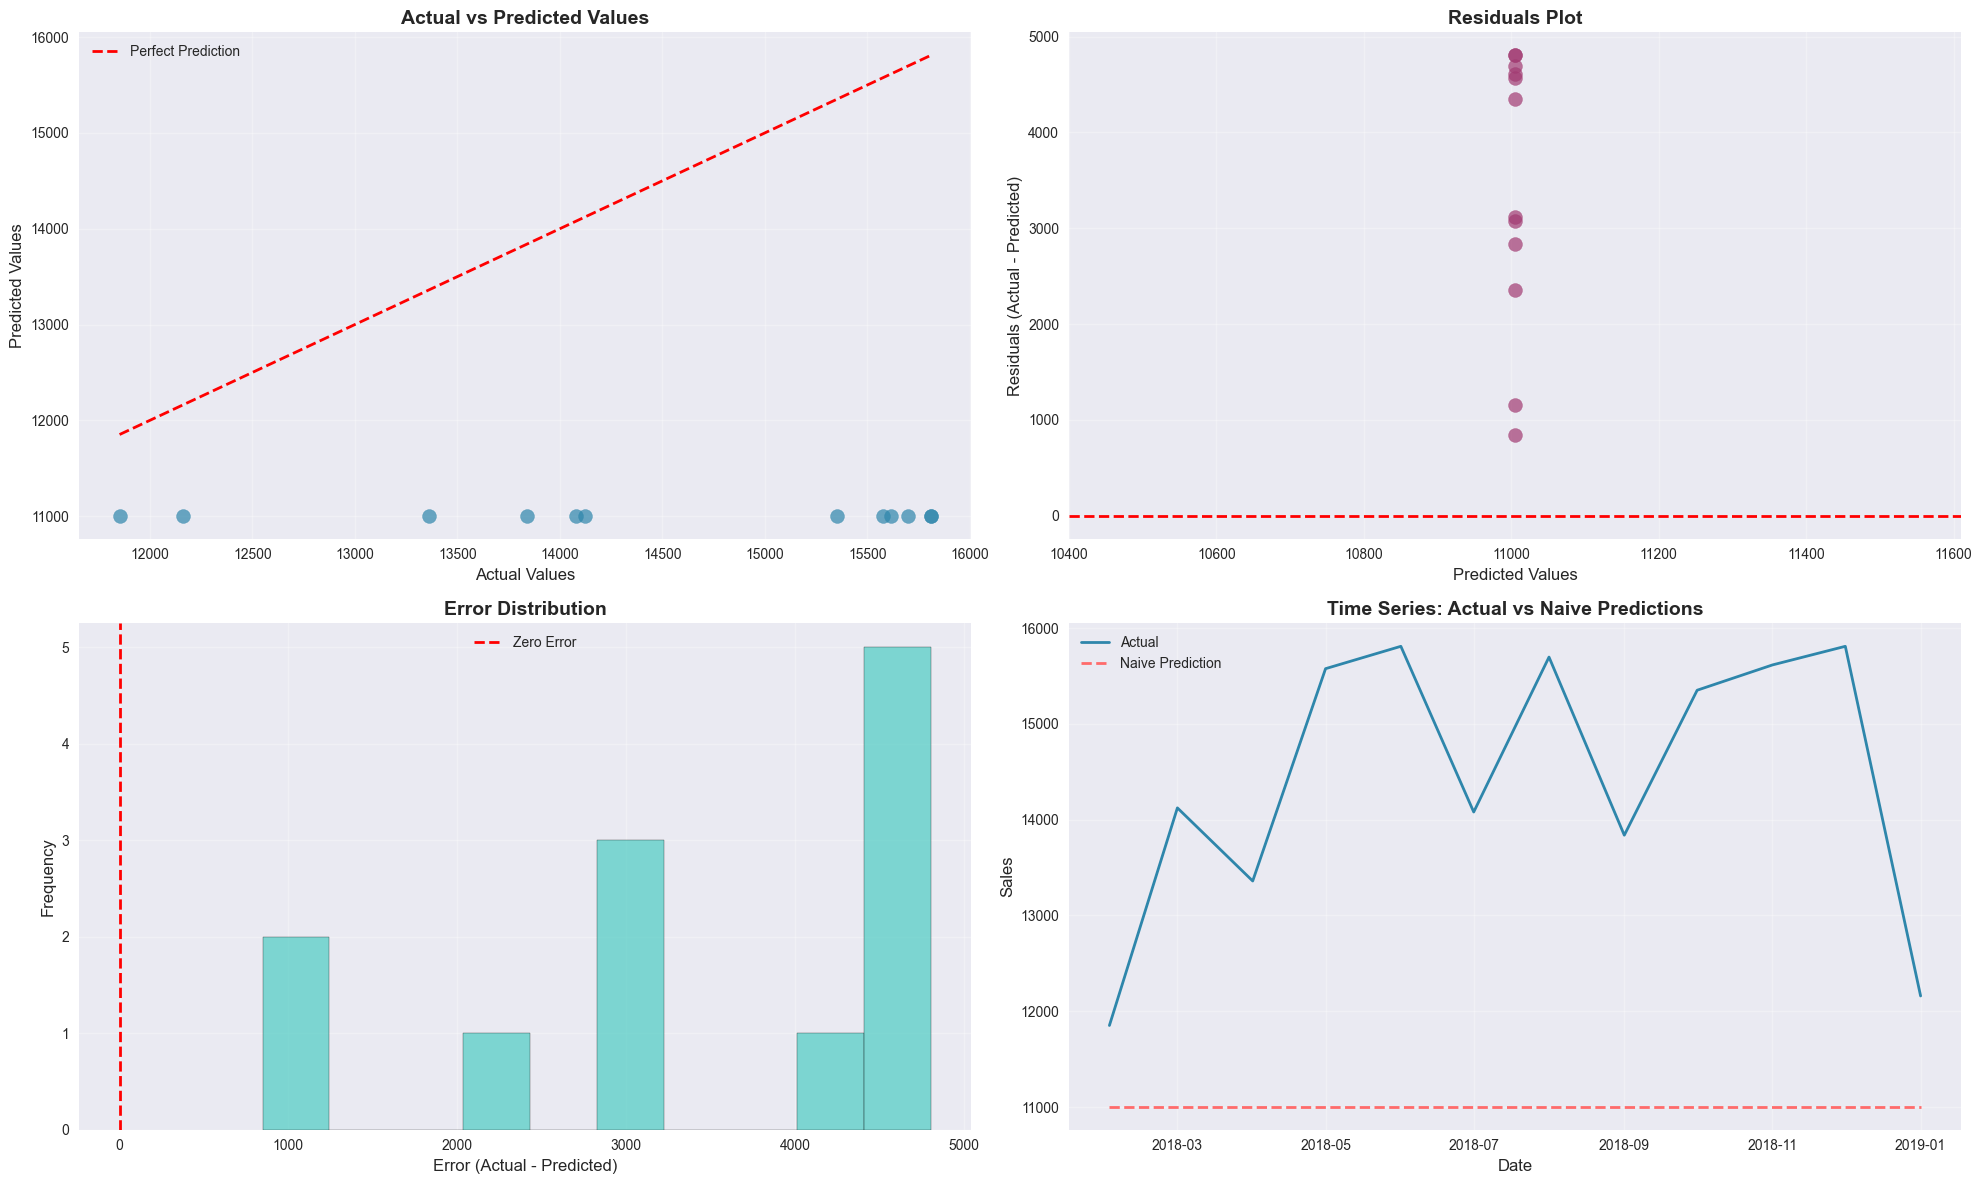

In [ ]:

# Create visualization of all metrics
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 12))

# 1. Actual vs Predicted scatter plot
ax1.scatter(actual_values, predicted_values, alpha=0.7, color='#2E86AB', s=100)
ax1.plot([actual_values.min(), actual_values.max()], 
         [actual_values.min(), actual_values.max()], 'r--', lw=2, label='Perfect Prediction')
ax1.set_xlabel('Actual Values', fontsize=12)
ax1.set_ylabel('Predicted Values', fontsize=12)
ax1.set_title('Actual vs Predicted Values', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Residuals plot
residuals = actual_values - predicted_values
ax2.scatter(predicted_values, residuals, alpha=0.7, color='#A23B72', s=100)
ax2.axhline(y=0, color='r', linestyle='--', lw=2)
ax2.set_xlabel('Predicted Values', fontsize=12)
ax2.set_ylabel('Residuals (Actual - Predicted)', fontsize=12)
ax2.set_title('Residuals Plot', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# 3. Error distribution
ax3.hist(residuals, bins=10, alpha=0.7, color='#4ECDC4', edgecolor='black')
ax3.axvline(x=0, color='r', linestyle='--', lw=2, label='Zero Error')
ax3.set_xlabel('Error (Actual - Predicted)', fontsize=12)
ax3.set_ylabel('Frequency', fontsize=12)
ax3.set_title('Error Distribution', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Time series comparison
ax4.plot(test_data.index, actual_values, label='Actual', color='#2E86AB', linewidth=2)
ax4.plot(test_data.index, predicted_values, label='Naive Prediction', 
         color='#FF6B6B', linestyle='--', linewidth=2)
ax4.set_xlabel('Date', fontsize=12)
ax4.set_ylabel('Sales', fontsize=12)
ax4.set_title('Time Series: Actual vs Naive Predictions', fontsize=14, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:

# Model performance assessment

if mape_sklearn < 0.1:
    performance = "Excellent"
elif mape_sklearn < 0.2:
    performance = "Good"
elif mape_sklearn < 0.3:
    performance = "Fair"
else:
    performance = "Poor"

print(f"Overall Performance: {performance}")
print(f"MAPE: {mape_sklearn * 100:.2f}%")
print(f"MAE: {mae_sklearn:.2f} units")
print(f"RMSE: {rmse:.2f} units")

print(f"\n💡 Key Insights:")
print(f"   • The Naive model shows {'positive' if mean_error > 0 else 'negative'} bias")
print(f"   • Average prediction error is {mape_sklearn * 100:.1f}% of actual values")
print(f"   • RMSE is {rmse/mae_sklearn:.2f}x larger than MAE, indicating some large errors")
print(f"   • The model {'underestimates' if mean_error > 0 else 'overestimates'} sales on average")

print(f"\nNext Steps:")
print(f"   • Consider more sophisticated forecasting models (ARIMA, Prophet, etc.)")
print(f"   • Analyze seasonal patterns in the data")
print(f"   • Implement trend analysis and decomposition")
print(f"   • Try ensemble methods for better accuracy")

Overall Performance: Fair
MAPE: 23.04%
MAE: 3434.23 units
RMSE: 3697.00 units

💡 Key Insights:
   • The Naive model shows positive bias
   • Average prediction error is 23.0% of actual values
   • RMSE is 1.08x larger than MAE, indicating some large errors
   • The model underestimates sales on average

Next Steps:
   • Consider more sophisticated forecasting models (ARIMA, Prophet, etc.)
   • Analyze seasonal patterns in the data
   • Implement trend analysis and decomposition
   • Try ensemble methods for better accuracy


So, we can see that the Naive Method of forecasting is not a very good performing method.

In the next lecture, we will look at other models of forecasting a time series.